<h1 style="font-size:5em; font-family:fantasy; color:#00204a; font-weight:700;">Hotel Booking Project</h1>

<h1 style="font-size:3em;  font-family:roboto, sans-serif; color:#005792; font-weight:700">Objective</h1>
<ul style="font-size:1em; font-weight:400; color:#00bbf0">
    <li>Import Libraries</li>
    <li>Import Dataset</li>
    <li>Understanding Dataset</li>
    <li>Data Preperation</li>
    <li>Feature transformation</li>
    <li>New Feature Development</li>
    <li>Exporting Clean Dataset</li>
</ul>

<h2 style="color:#fdb44b; font-size:2em">Libraries</h2>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from datetime import date
from sklearn.preprocessing import LabelEncoder

<h2 style="font-size:2em; color:#fdb44b;">Data Understanding and Preperation</h2> 

In [68]:
# Fetching dataset 
df = pd.read_csv("hotel_bookings.csv")

In [69]:
# data overview
pd.set_option("display.max_columns" , None) 
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [70]:
# Understanding dataset 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [71]:
# required pattern's from dataset we have total count , average , standard of deviation value , min value , max value, q1 , q2 and q3
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [72]:
# columns with null values
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [73]:
# Duplicated value
df.duplicated().sum()

31994

In [74]:
# removing 31994 rows
df.drop_duplicates(inplace=True)

In [75]:
# value count of columns 
encoder={}
for i in df.columns:
    if df[i].dtype ==object:
        encoder[i]=df[i].value_counts().keys()
# need to fix reservation_status_date

In [76]:
# checking null value again
df.isna().sum()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             452
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             12193
company                           82137


In [77]:
# Filling null values
# Replace missing values safely
df["agent"]   = df["agent"].fillna(0)
df["company"] = df["company"].fillna(0)
df["children"] = df["children"].fillna(df["children"].mean())
df["country"]  = df["country"].fillna(df["country"].mode()[0])

<h3 style="color:#edb1f1">Outlier Detention and Removal</h3>

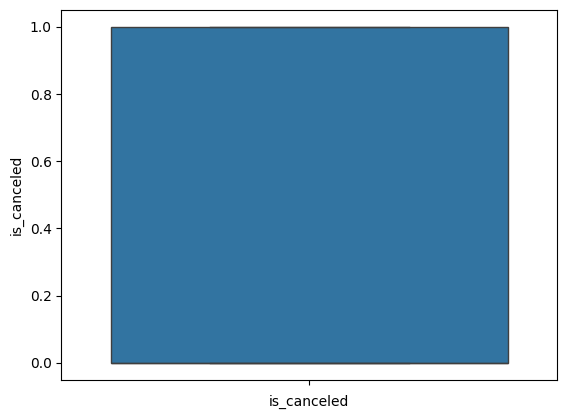

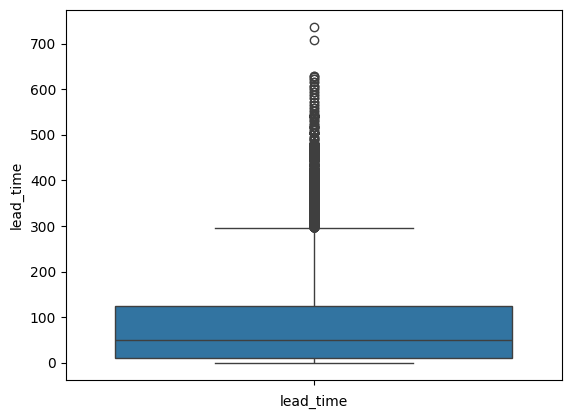

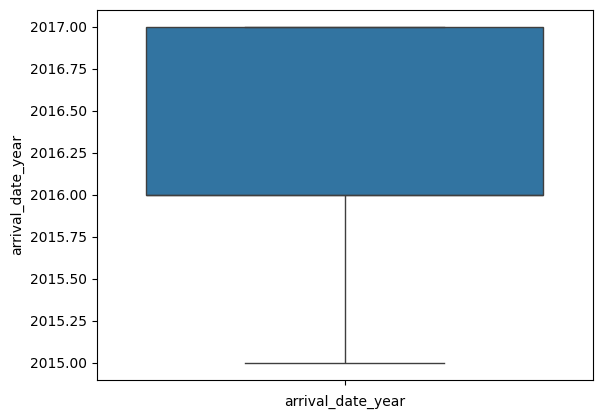

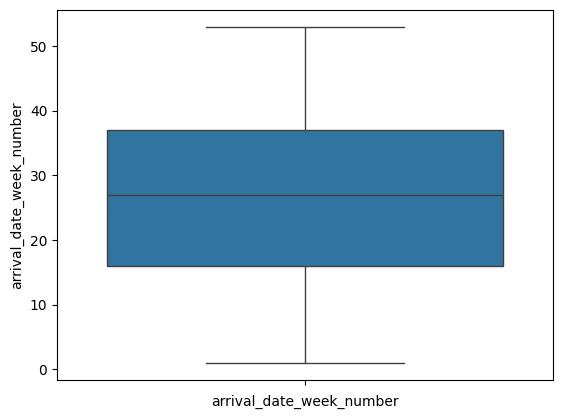

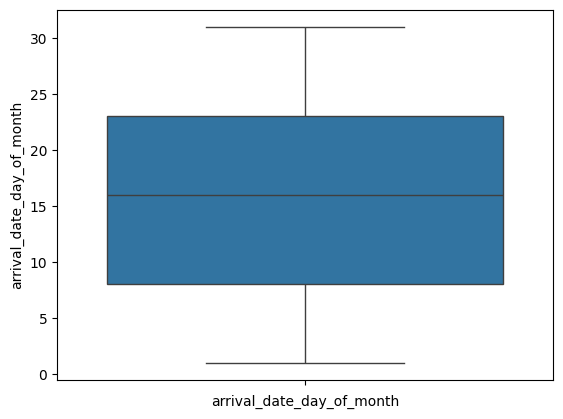

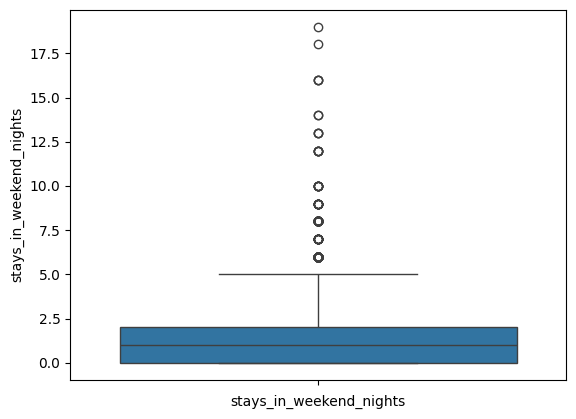

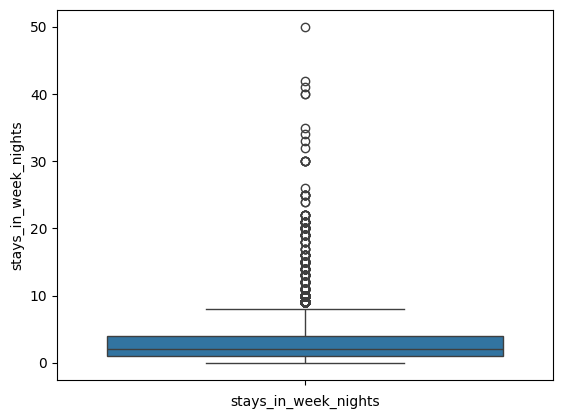

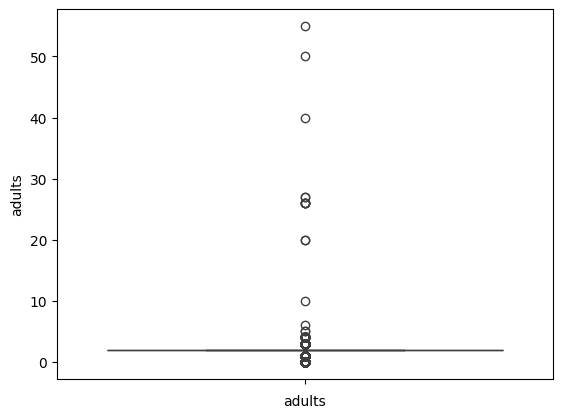

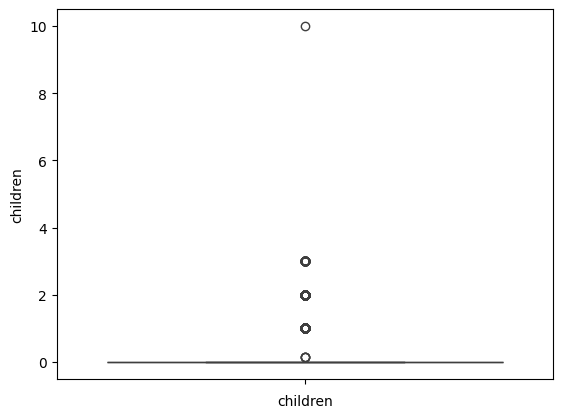

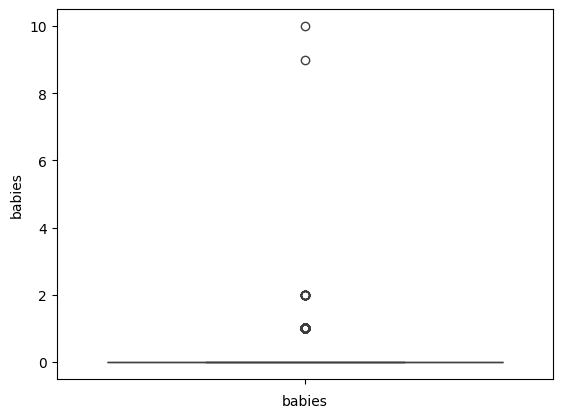

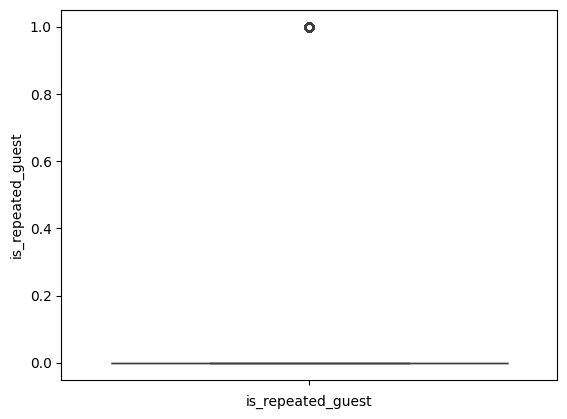

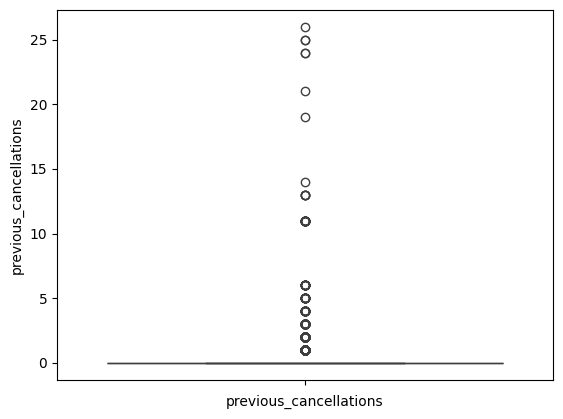

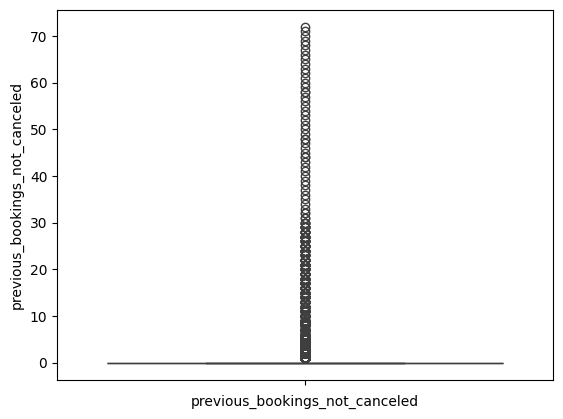

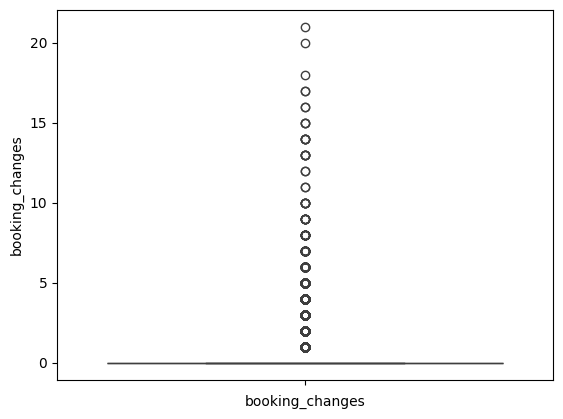

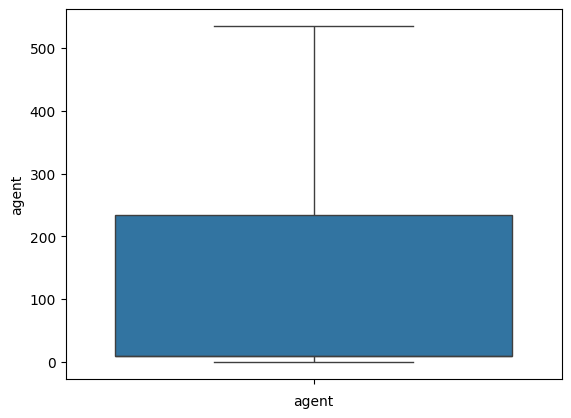

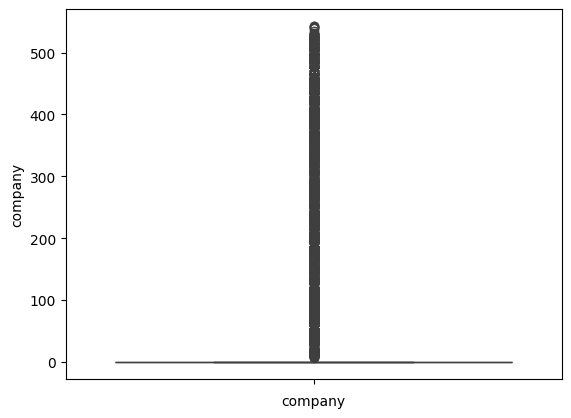

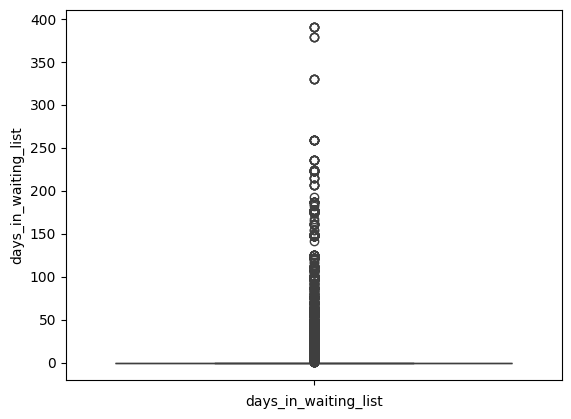

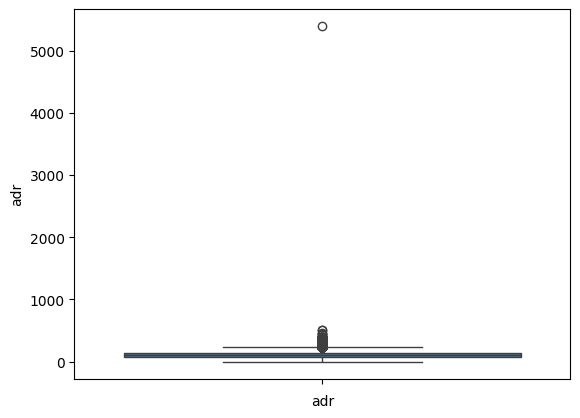

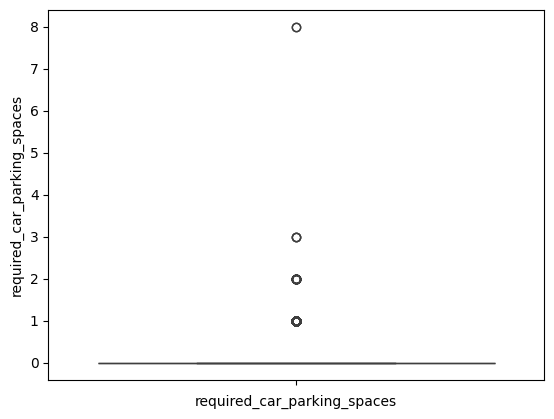

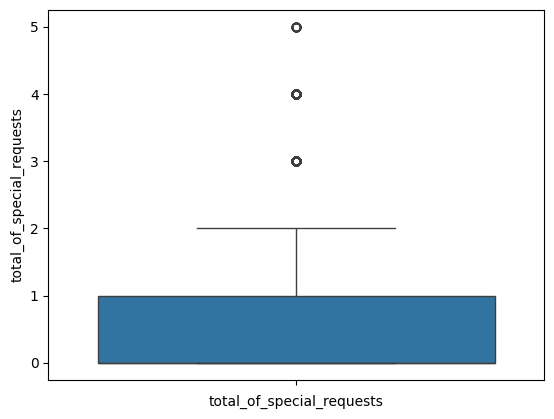

In [78]:
# Outlier Detention
for i in df.columns:
    if df[i].dtype !=object:
        sns.boxplot(df[i])
        plt.xlabel(i)
        plt.show()
# we will only focuses on removing outlier in average daily rate column

In [79]:
# Outlier Removal
for i in outlier_col:
    # Quantile 1 and Quantile 3
    Q1= df["adr"].quantile(0.25)
    Q3= df["adr"].quantile(0.75)

    # Interquantile Range
    IQR = Q3-Q1

    # Upper and Lower fench value
    Upper = Q3 + 1.5 * IQR
    Lower = Q1 - 1.5 * IQR
    
    # filtering and putting back outlier removed value
    df = df[(df["adr"]>=Lower) & (df["adr"]<=Upper)]
    

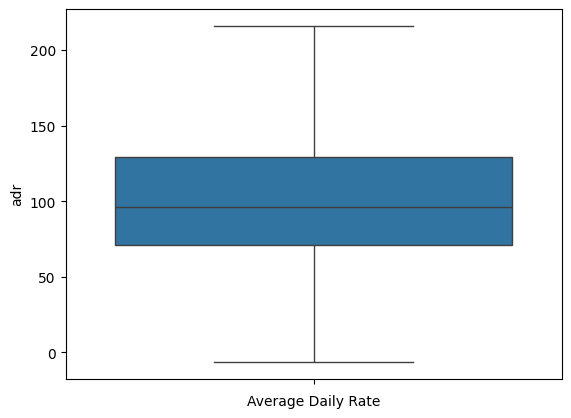

In [80]:
# checking outlier removed col
sns.boxplot(df["adr"])
plt.xlabel("Average Daily Rate")
plt.show()

In [82]:
# fixing reservation_status_date
day=[]
month=[]
year=[]
rev_date = pd.to_datetime(df["reservation_status_date"])
for i in rev_date:
    # fetching day
    day.append(i.day)
    # fetching month
    month.append(i.month)
    # fetching year
    year.append(i.year)

In [83]:
# putting back value 
df["reservation_status_day"]= day
df["reservation_status_month"]=month
df["reservation_status_year"]=year

In [84]:
# dropping reservation_status_date
df.drop('reservation_status_date',axis=1,inplace=True)

<h2 style="font-size:2em;color:#fdb44b;">Feature Engineering</h2>

<h3 style="color:#edb1f1">Feature Transformation</h3>

In [85]:
df_copy = df.copy() # copying dataset
encoder={}
for i in df_copy.columns:
    if df_copy[i].dtype == object:
        label = LabelEncoder()
        df_copy[i]=label.fit_transform(df_copy[i])
        encoder[i]=label

<h3 style="color:#edb1f1;">Feature Development</h3>

In [86]:
# Guest Total stays in hotel 
df_copy["guest_total_stay"]= df_copy["stays_in_weekend_nights"]+df_copy["stays_in_week_nights"]
# Long stay guest 
df_copy["is_stay_long"]=[ 1 if i > 7  else 0 for i in df_copy["guest_total_stay"] ]
# total revenue per booking 
df_copy["total_revenue"] = df_copy["adr"] * df_copy["guest_total_stay"] 


<h3 style="color:#edb1f1;">Exporting Dataset</h3>

In [88]:
df_copy.to_csv(r"c:/users/gautam/downloads/hotel_booking_clean_1.csv",index=False)
df.to_csv(r"c:/users/gautam/downloads/hotel_booking_clean_2.csv",index=False)